<a href="https://colab.research.google.com/github/shpakandrew15-netizen/ml_course_homeworks/blob/main/hw01_setup_tools.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HW01 — Setup tools + first steps in Jupyter / NumPy / Pandas

Этот ноутбук — шаблон для первой домашней работы.

## Как пользоваться
1. Откройте ноутбук в Jupyter/VS Code/Colab.
2. Запускайте ячейки сверху вниз.
3. В местах с `TODO` допишите код.
4. Перед сдачей: **Restart Kernel → Run All** (ноутбук должен выполняться без ошибок).

---


## 1) Проверка окружения

Цель: убедиться, что установлены нужные библиотеки и вы работаете в правильном окружении (kernel).


In [1]:
import sys
import platform

import numpy as np
import pandas as pd

try:
    import sklearn
except Exception as e:
    sklearn = None
    print("⚠️ scikit-learn не импортируется:", e)

print("Python:", sys.version.split()[0])
print("Executable:", sys.executable)
print("OS:", platform.platform())

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
if sklearn is not None:
    print("scikit-learn:", sklearn.__version__)


Python: 3.12.12
Executable: /usr/bin/python3
OS: Linux-6.6.113+-x86_64-with-glibc2.35
NumPy: 2.0.2
Pandas: 2.2.2
scikit-learn: 1.6.1


## 2) pip внутри ноутбука (инструкция)

Иногда нужно поставить пакет прямо отсюда.

**Локально (рекомендация):**
```python
%pip install -U numpy pandas matplotlib seaborn scikit-learn
```

**Colab / универсально:**
```python
!pip install -U numpy pandas matplotlib seaborn scikit-learn
```

Если после установки импорт не работает — перезапустите kernel.


## 3) NumPy: создаём матрицу 100×5 и считаем статистики

### Задание 3.1
- Создайте случайную матрицу `X` размера **(100, 5)** (например, `np.random.randn`).
- Зафиксируйте seed для воспроизводимости.
- Выведите:
  - `X.shape`
  - `X.dtype`
  - первые 5 строк матрицы

### Задание 3.2
Посчитайте статистики:
- среднее и стандартное отклонение **по всей матрице**
- среднее и стандартное отклонение **по каждому столбцу** (axis=0)
- минимум/максимум по каждому столбцу

> Подсказка: `X.mean()`, `X.mean(axis=0)`, `X.std(axis=0)`, `X.min(axis=0)`, `X.max(axis=0)`.


In [2]:
# TODO: зафиксируйте seed
np.random.seed(42)

# TODO: создайте матрицу 100x5
X = np.random.randn(100, 5)

print("X.shape:", X.shape)
print("X.dtype:", X.dtype)
print("First 5 rows:\n", X[:5])


X.shape: (100, 5)
X.dtype: float64
First 5 rows:
 [[ 0.49671415 -0.1382643   0.64768854  1.52302986 -0.23415337]
 [-0.23413696  1.57921282  0.76743473 -0.46947439  0.54256004]
 [-0.46341769 -0.46572975  0.24196227 -1.91328024 -1.72491783]
 [-0.56228753 -1.01283112  0.31424733 -0.90802408 -1.4123037 ]
 [ 1.46564877 -0.2257763   0.0675282  -1.42474819 -0.54438272]]


In [3]:
# TODO: статистики по всей матрице
overall_mean = X.mean()
overall_std = X.std()

# TODO: статистики по столбцам
col_mean = X.mean(axis=0)
col_std = X.std(axis=0)
col_min = X.min(axis=0)
col_max = X.max(axis=0)

print("Overall mean:", overall_mean)
print("Overall std:", overall_std)
print("\nPer-column mean:", col_mean)
print("Per-column std:", col_std)
print("Per-column min:", col_min)
print("Per-column max:", col_max)


Overall mean: 0.006837994588647575
Overall std: 0.9802715029966268

Per-column mean: [-0.04474719  0.07695423 -0.09387351  0.12805847 -0.03220203]
Per-column std: [0.89583921 0.9791772  0.97901142 0.95474576 1.06742857]
Per-column min: [-1.9520878  -2.30192116 -3.24126734 -1.91328024 -2.6197451 ]
Per-column max: [2.31465857 1.8861859  2.1221562  3.07888081 3.85273149]


## 4) Векторизация: `y = X @ w`

В ML часто встречается линейная комбинация признаков.

### Задание 4.1
- Создайте вектор весов `w` размера (5,)
- Посчитайте `y = X @ w`
- Выведите `y.shape` и несколько первых значений

### Задание 4.2 (мини-метрики регрессии)
- Сгенерируйте “истинную” цель: `y_true = X @ w_true + noise`
- Сгенерируйте предсказание: `y_pred = X @ w_guess`
- Посчитайте **MSE**, **MAE**, **RMSE**
- (Бонус) Посчитайте **R2** вручную

> Подсказка:  
> MSE = mean((y_true - y_pred)^2)  
> MAE = mean(abs(y_true - y_pred))  
> RMSE = sqrt(MSE)  
> R2 = 1 - SS_res / SS_tot


In [4]:
# TODO: веса и линейная комбинация
w = np.random.randn(5)
y = X @ w

print("w:", w)
print("y.shape:", y.shape)
print("y[:5]:", y[:5])


w: [ 0.92617755  1.90941664 -1.39856757  0.56296924 -0.65064257]
y.shape: (100,)
y[:5]: [ 0.29997426  1.10790121 -1.61169274 -2.48647552  0.38401638]


In [5]:
# TODO: "истинные" веса, шум, y_true
w_true = np.array([1.5, -2.0, 0.0, 0.7, 3.0])
noise = 0.1 * np.random.randn(X.shape[0])
y_true = X @ w_true + noise

# TODO: "предсказанные" веса и y_pred (можете взять w_true + небольшой шум)
w_guess = w_true + 0.5 * np.random.randn(5)
y_pred = X @ w_guess

# Метрики
mse = np.mean((y_true - y_pred) ** 2)
mae = np.mean(np.abs(y_true - y_pred))
rmse = np.sqrt(mse)

# TODO (bonus): R2
ss_res = np.sum((y_true - y_pred) ** 2)
ss_tot = np.sum((y_true - y_true.mean()) ** 2)
r2 = 1 - ss_res / ss_tot

print("MSE:", mse)
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)


MSE: 2.6179517731099695
MAE: 1.2687155830236363
RMSE: 1.6180085825204913
R2: 0.8296792210419167


## 5) Pandas: DataFrame, describe, пропуски, фильтры, groupby

### Задание 5.1
- Создайте DataFrame `df` из матрицы `X`
- Назовите колонки, например: `x0, x1, x2, x3, x4`
- Добавьте столбец `target` = `y_true`

### Задание 5.2
- Выведите `df.head()`, `df.shape`, `df.describe()`
- Проверьте пропуски: `df.isnull().sum()`

### Задание 5.3
- Создайте категориальный столбец (например, бины по `x0`)
- Сделайте `groupby` и посчитайте среднее `target` в группах


In [6]:
# TODO: DataFrame из X
col_names = [f"x{i}" for i in range(X.shape[1])]
df = pd.DataFrame(X, columns=col_names)

# TODO: добавьте target
df["target"] = y_true

display(df.head())
print("Shape:", df.shape)
display(df.describe())
print("\nMissing values:\n", df.isnull().sum())


,x0,x1,x2,x3,x4,target
0,0.496714,-0.138264,0.647689,1.523030,-0.234153,1.336548
1,-0.234137,1.579213,0.767435,-0.469474,0.542560,-2.269822
2,-0.463418,-0.465730,0.241962,-1.913280,-1.724918,-6.364116
3,-0.562288,-1.012831,0.314247,-0.908024,-1.412304,-3.685445
4,1.465649,-0.225776,0.067528,-1.424748,-0.544383,-0.063541


Shape: (100, 6)


,x0,x1,x2,x3,x4,target
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,-0.044747,0.076954,-0.093874,0.128058,-0.032202,-0.238401
std,0.900352,0.984110,0.983943,0.959556,1.072806,3.940301
min,-1.952088,-2.301921,-3.241267,-1.913280,-2.619745,-9.222826
25%,-0.734897,-0.678136,-0.700307,-0.536288,-0.757046,-3.315029
50%,-0.010110,0.066421,-0.024662,0.152465,-0.145714,-1.036352
75%,0.524237,0.830645,0.532419,0.667929,0.648170,2.600386
max,2.314659,1.886186,2.122156,3.078881,3.852731,10.120710



Missing values:
 x0        0
x1        0
x2        0
x3        0
x4        0
target    0
dtype: int64


In [7]:
# TODO: пример фильтрации и сортировки (поменяйте условие на своё)
filtered = df[df["x0"] > 0].sort_values("target", ascending=False)
display(filtered.head(10))


,x0,x1,x2,x3,x4,target
35,0.827183,0.013002,1.453534,-0.264657,2.720169,9.273588
47,0.633919,-2.025143,0.186454,-0.661786,0.852433,7.211991
74,0.024510,0.497998,1.451144,0.959271,2.153182,6.286181
11,0.931280,-0.839218,-0.309212,0.331263,0.975545,6.283967
82,0.711615,-1.124642,-1.534114,1.277677,0.332314,5.123038
10,0.324084,-0.385082,-0.676922,0.611676,1.031000,4.853002
29,0.781823,-1.236951,-1.320457,0.521942,0.296985,4.837765
81,0.622850,-1.067620,-0.142379,0.120296,0.514439,4.651103
44,2.314659,-1.867265,0.686260,-1.612716,-0.471932,4.601423
56,0.113517,0.662131,1.586017,-1.237815,2.133033,4.586184


In [8]:
# TODO: создаём бины по x0 и делаем groupby
df["x0_bin"] = pd.cut(df["x0"], bins=4)

grouped = df.groupby("x0_bin")["target"].mean()
display(grouped)


/tmp/ipykernel_177/3836647185.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("x0_bin")["target"].mean()


,target
x0_bin,
"(-1.956, -0.885]",-1.104602
"(-0.885, 0.181]",-0.739662
"(0.181, 1.248]",0.361342
"(1.248, 2.315]",1.767438


## 6) Визуализация: распределения и корреляции

### Задание 6.1
Постройте гистограмму:
- одного признака (например, `x0`) или
- `target`

### Задание 6.2
Постройте тепловую карту корреляций по числовым колонкам.

> Подсказка: `df.corr(numeric_only=True)` (в новых версиях pandas).


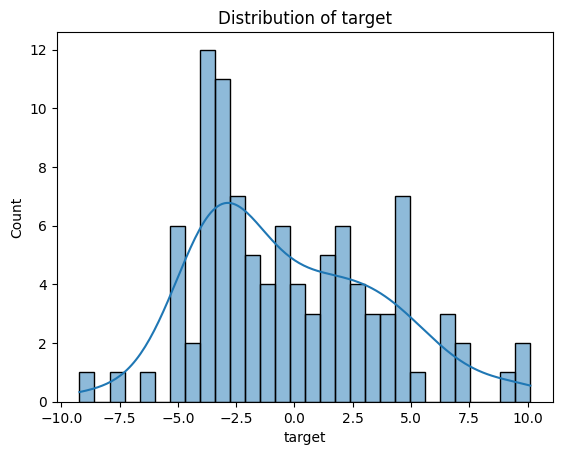

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# TODO: гистограмма
plt.figure()
sns.histplot(df["target"], bins=30, kde=True)
plt.title("Distribution of target")
plt.show()


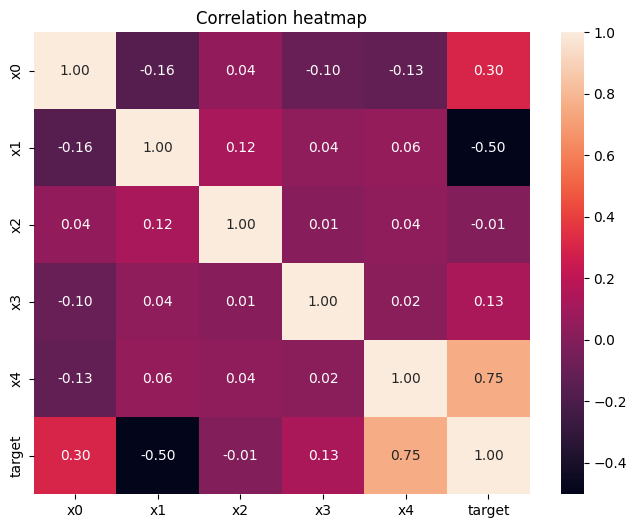

In [10]:
# TODO: корреляции
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation heatmap")
plt.show()


## 7) Бонус: Iris dataset + простая модель (sklearn)

В лекции упоминался датасет `sklearn.datasets.load_iris`.  
Здесь — небольшой “мини-пайплайн”: загрузка → EDA → train/test split → модель → метрика.

### Задание 7.1
- загрузить iris
- собрать DataFrame
- посмотреть `value_counts()` по классам
- визуализировать (хотя бы bar plot)

### Задание 7.2
- Разбить данные на train/test
- Обучить `LogisticRegression` (или любую другую простую модель)
- Посчитать accuracy на test

Если sklearn не установлен — вернитесь к README и поставьте зависимости.


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


Class distribution:
target
0    50
1    50
2    50
Name: count, dtype: int64


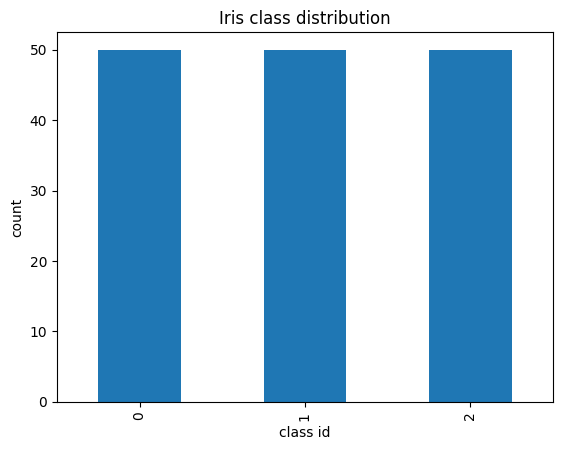

Accuracy: 0.9666666666666667

Confusion matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [11]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

iris = load_iris(as_frame=True)
iris_df = iris.frame.copy()
display(iris_df.head())

print("Class distribution:")
print(iris_df["target"].value_counts())

plt.figure()
iris_df["target"].value_counts().sort_index().plot(kind="bar")
plt.title("Iris class distribution")
plt.xlabel("class id")
plt.ylabel("count")
plt.show()

# Train/test split
X_iris = iris_df.drop(columns=["target"])
y_iris = iris_df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42, stratify=y_iris
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))


## 8) Что закоммитить

- Этот ноутбук с выполненными заданиями
- README с инструкциями
- (желательно) `requirements.txt` и `.gitignore` в корне репозитория

Перед коммитом проверьте:
- ноутбук запускается без ошибок (Restart & Run All)
- нет огромных выводов (тысячи строк) и больших файлов в репозитории
